# Money-Market Rates

Exploring SOFR, Fed Funds, and the 3-month T-bill yield — and contrasting interest-rate autocorrelation with equity returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Load Data

In [2]:
rates = pd.read_excel('data/ref_rates.xlsx', sheet_name='data', parse_dates=['date'])
rates = rates.set_index('date').rename(columns={
    'DTB3': 'T-Bill 3M',
    'DFF':  'Fed Funds',
    'SOFR': 'SOFR',
})

print(f'Rates data: {rates.index.min().date()} to {rates.index.max().date()}  ({len(rates):,} rows)')
rates.tail()

Rates data: 2018-01-01 to 2026-06-05  (3,078 rows)


,T-Bill 3M,Fed Funds,SOFR
date,,,
2026-06-01,3.63,3.62,3.65
2026-06-02,3.63,3.62,3.63
2026-06-03,3.63,3.62,3.61
2026-06-04,3.63,3.62,3.62
2026-06-05,NaN,NaN,3.63


In [3]:
spy_prices  = pd.read_excel('data/spy_data_daily.xlsx', sheet_name='prices',       parse_dates=['date']).set_index('date')['SPY']
spy_returns = pd.read_excel('data/spy_data_daily.xlsx', sheet_name='total returns', parse_dates=['date']).set_index('date')['SPY']

print(f'SPY data: {spy_prices.index.min().date()} to {spy_prices.index.max().date()}  ({len(spy_prices):,} rows)')

SPY data: 1994-01-03 to 2026-06-12  (8,166 rows)


---
## 2. Plot the Time Series

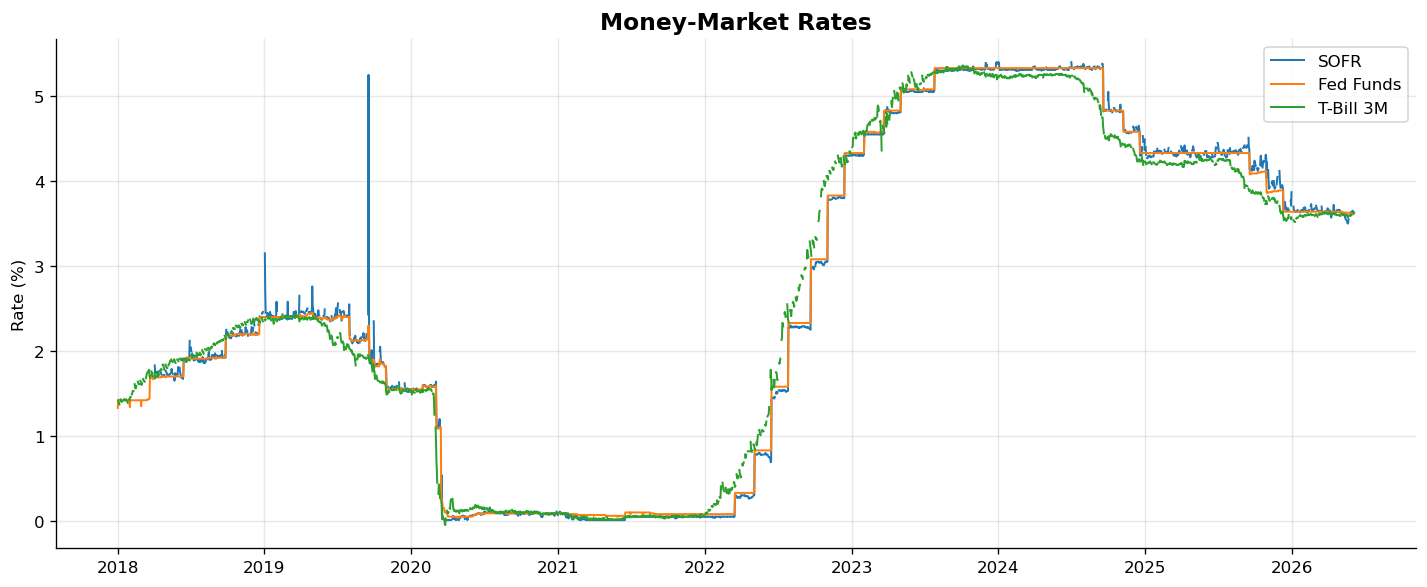

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'SOFR': '#1f77b4', 'Fed Funds': '#ff7f0e', 'T-Bill 3M': '#2ca02c'}
for col, color in colors.items():
    ax.plot(rates.index, rates[col], label=col, color=color, linewidth=1.2)

ax.set_title('Money-Market Rates', fontsize=14, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

The three rates track each other very closely — all are overnight or short-term USD rates anchored by Fed policy. The main divergences occur during Fed rate-change cycles and briefly around COVID-19 (early 2020), when T-bill yields briefly dislocated below SOFR and Fed Funds.

---
## 3. Correlation Analysis

We filter to dates where all three rates are reported.

In [5]:
common = rates.dropna()
print(f'Common observation window: {common.index.min().date()} to {common.index.max().date()}  ({len(common):,} rows)')

Common observation window: 2018-04-03 to 2026-06-04  (2,041 rows)


### 3a. Correlation in Levels

In [6]:
corr_levels = common.corr()
print('Correlation — Levels')
corr_levels.round(4)

Correlation — Levels


,T-Bill 3M,Fed Funds,SOFR
T-Bill 3M,1.0000,0.9947,0.9929
Fed Funds,0.9947,1.0000,0.9991
SOFR,0.9929,0.9991,1.0000


### 3b. Correlation in Differences (Day-over-Day Changes)

In [7]:
diffs = common.diff().dropna()
corr_diffs = diffs.corr()
print('Correlation — Differences')
corr_diffs.round(4)

Correlation — Differences


,T-Bill 3M,Fed Funds,SOFR
T-Bill 3M,1.0000,0.0080,0.0375
Fed Funds,0.0080,1.0000,0.4965
SOFR,0.0375,0.4965,1.0000


**Interpretation.** In *levels*, all three rates are nearly perfectly correlated (≈ 0.99+) — they all move with the Fed policy cycle over time. In *differences*, correlations drop substantially. Fed Funds and SOFR remain tightly linked day-to-day (both are overnight rates), but the T-bill yield is a market rate that adjusts with supply, demand, and expectations and so is less synchronised on a daily basis.

---
## 4. Autoregression for SOFR

We regress today's SOFR on yesterday's SOFR:

$$\text{SOFR}_t = \alpha + \beta \cdot \text{SOFR}_{t-1} + \varepsilon_t$$

In [8]:
sofr = rates['SOFR'].dropna()
y = sofr.values[1:]
x = sofr.values[:-1]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

print(f'AR(1) for SOFR')
print(f'  Beta (slope):  {slope:.6f}')
print(f'  Intercept:     {intercept:.6f}')
print(f'  R-squared:     {r_squared:.6f}')
print(f'  p-value:       {p_value:.2e}')

AR(1) for SOFR
  Beta (slope):  0.998519
  Intercept:     0.004804
  R-squared:     0.997003
  p-value:       0.00e+00


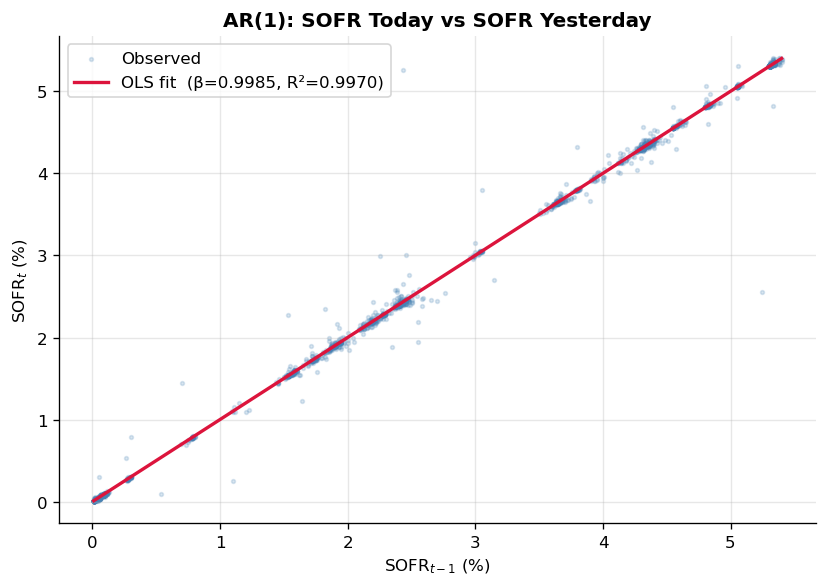

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.2, s=5, color='steelblue', label='Observed')
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='crimson', linewidth=2,
        label=f'OLS fit  (β={slope:.4f}, R²={r_squared:.4f})')
ax.set_xlabel('SOFR$_{t-1}$ (%)')
ax.set_ylabel('SOFR$_t$ (%)')
ax.set_title('AR(1): SOFR Today vs SOFR Yesterday', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.**

- **β ≈ 1.00** and **R² ≈ 1.00**: yesterday's SOFR explains essentially all of today's SOFR. The series is extremely persistent — it behaves close to a *random walk with drift*, or more formally an AR(1) with a unit root.
- **Can we forecast the next period's rate?** In a narrow sense yes — predicting "tomorrow's rate will be almost exactly today's rate" is highly accurate. But this is a trivial forecast: it tells us the *level* will persist, not *where* rates are heading.
- **Autocorrelation**: SOFR is strongly positively autocorrelated. Interest rates tend to remain near their current value for extended periods, then shift gradually with Fed policy. They do not mean-revert quickly. This property (near-unit-root persistence) is characteristic of interest rates and other macro variables, and it stands in sharp contrast with asset *returns* (see next section).

---
## 5. Autoregression for SPY

We run the same AR(1) on SPY **returns** and then on SPY **prices**.

In [10]:
ret = spy_returns.dropna()

y_r = ret.values[1:]
x_r = ret.values[:-1]

slope_r, intercept_r, r_r, p_r, se_r = stats.linregress(x_r, y_r)
r2_r = r_r**2

print('AR(1) for SPY Daily Returns')
print(f'  Beta (slope):  {slope_r:.6f}')
print(f'  Intercept:     {intercept_r:.6f}')
print(f'  R-squared:     {r2_r:.6f}')
print(f'  p-value:       {p_r:.4f}')

AR(1) for SPY Daily Returns
  Beta (slope):  -0.082877
  Intercept:     0.000519
  R-squared:     0.006869
  p-value:       0.0000


In [11]:
px = spy_prices.dropna()

y_p = px.values[1:]
x_p = px.values[:-1]

slope_p, intercept_p, r_p, p_p, se_p = stats.linregress(x_p, y_p)
r2_p = r_p**2

print('AR(1) for SPY Daily Prices')
print(f'  Beta (slope):  {slope_p:.6f}')
print(f'  Intercept:     {intercept_p:.6f}')
print(f'  R-squared:     {r2_p:.6f}')
print(f'  p-value:       {p_p:.2e}')

AR(1) for SPY Daily Prices
  Beta (slope):  1.000590
  Intercept:     -0.016158
  R-squared:     0.999760
  p-value:       0.00e+00


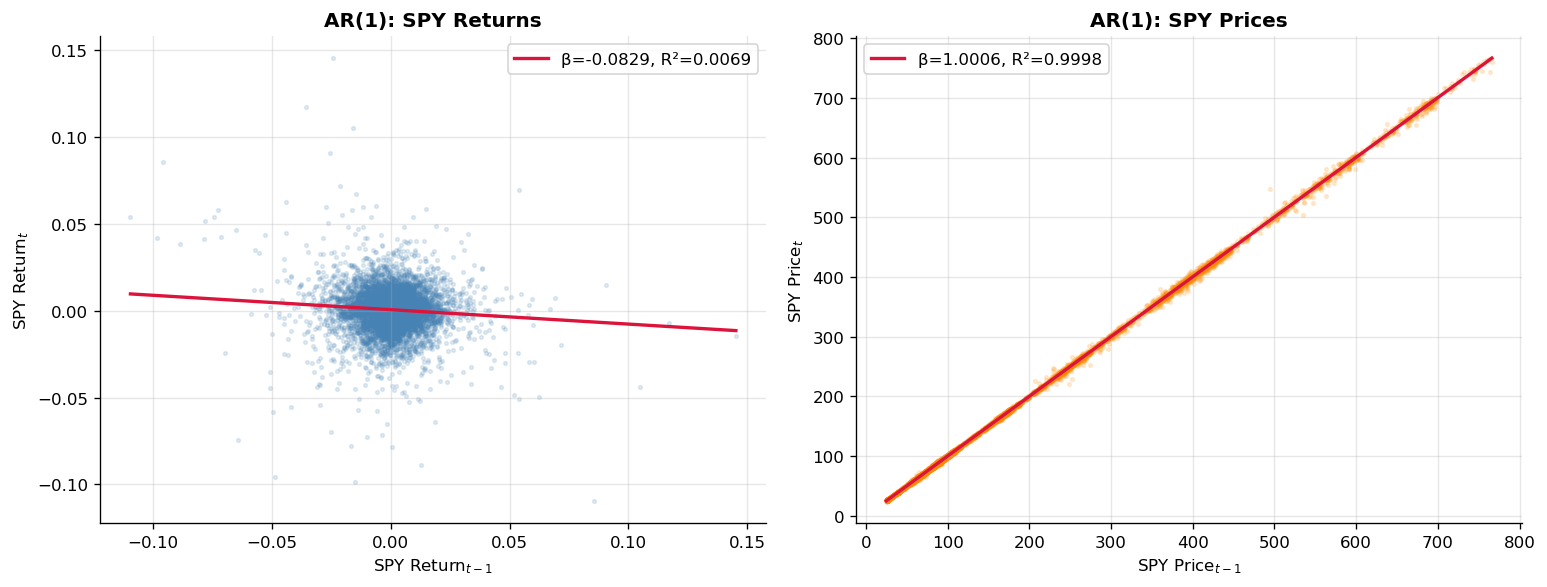

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Returns
ax = axes[0]
ax.scatter(x_r, y_r, alpha=0.15, s=5, color='steelblue')
x_line = np.linspace(x_r.min(), x_r.max(), 200)
ax.plot(x_line, intercept_r + slope_r * x_line, color='crimson', linewidth=2,
        label=f'β={slope_r:.4f}, R²={r2_r:.4f}')
ax.set_xlabel('SPY Return$_{t-1}$')
ax.set_ylabel('SPY Return$_t$')
ax.set_title('AR(1): SPY Returns', fontweight='bold')
ax.legend()

# Prices
ax = axes[1]
ax.scatter(x_p, y_p, alpha=0.15, s=5, color='darkorange')
x_line = np.linspace(x_p.min(), x_p.max(), 200)
ax.plot(x_line, intercept_p + slope_p * x_line, color='crimson', linewidth=2,
        label=f'β={slope_p:.4f}, R²={r2_p:.4f}')
ax.set_xlabel('SPY Price$_{t-1}$')
ax.set_ylabel('SPY Price$_t$')
ax.set_title('AR(1): SPY Prices', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation.**

| | β | R² |
|---|---|---|
| SOFR (level) | ≈ 1.000 | ≈ 1.000 |
| SPY Returns | ≈ 0 | ≈ 0 |
| SPY Prices | ≈ 1.000 | ≈ 1.000 |

- **SPY returns are not autocorrelated.** β ≈ 0 and R² ≈ 0. Yesterday's return contains almost no information about today's return. This is consistent with the *Efficient Market Hypothesis*: in a competitive market, prices quickly incorporate available information, so past returns cannot be used to predict future returns.

- **SPY prices are highly autocorrelated** — just like SOFR levels. This is not surprising: a price series that grows over time will mechanically show persistence. The useful transformation is *returns* (i.e., differences in log prices), which removes this spurious autocorrelation.

- **The key contrast with SOFR**: interest rate *levels* are autocorrelated (β ≈ 1, R² ≈ 1) in the same way SPY *prices* are. But rate *changes* (differences) also show much less predictability, similar to SPY returns. The difference is that interest rate changes have some short-run structure driven by Fed policy signaling, whereas equity returns have essentially none.